# 📐 Series de Taylor y Métodos Numéricos
### Actividad de Cálculo Numérico — Universidad

| Ejercicio | Tema |
|-----------|------|
| **2** | Aproximación lineal de sin(x) |
| **3** | Serie de Taylor para e^(x²) + `my_double_exp` |
| **5** | Taylor orden 4: sin(x), cos(x) y sin(x)cos(x) |

> **Librerías:** `numpy`, `matplotlib`, `sympy`, `math`


---
## ⚙️ Imports y configuración global

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from math import factorial
from sympy import (symbols, sin, cos, exp, series, limit,
                   diff, pi, Rational, collect, expand, oo)

# Crear directorio para graficas si no existe
os.makedirs('series_taylor_graficas', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        12,
    'lines.linewidth':  2.2,
})

AZUL   = '#2563eb'
ROJO   = '#dc2626'
VERDE  = '#16a34a'
NEGRO  = '#111827'
NARANJA= '#ea580c'
print("✅ Imports y directorios configurados.")


✅ Imports y directorios configurados.


---
## 📌 Ejercicio 2 — Aproximación Lineal de sin(x)

### Enunciado
Usar la **aproximación lineal** de $\sin(x)$ alrededor de $a = 0$ para demostrar
que $\dfrac{\sin(x)}{x} \approx 1$ para $x$ suficientemente pequeño.

### Fundamento teórico
La aproximación lineal (Taylor orden 1) de $f(x)$ en $a=0$ es:

$$P_1(x) = f(0) + f'(0)\cdot x$$

Para $f(x) = \sin(x)$:
- $f(0) = \sin(0) = 0$
- $f'(x) = \cos(x) \Rightarrow f'(0) = 1$

$$\therefore\quad \sin(x) \approx x \quad\Longrightarrow\quad \frac{\sin(x)}{x}\approx 1$$

**Cota del error** (Teorema del Resto de Taylor, $n=1$, $M=\max|f''|=1$):

$$|E_1(x)| = |\sin(x) - x| \leq \frac{x^2}{2}$$


### 🔧 Celda 1 — Definición de funciones

In [15]:
def linear_approx_sin(x):
    """Aproximacion lineal de sin(x) en a=0: P1(x) = x"""
    return np.asarray(x, dtype=float)

def error_bound_sin(x):
    """Cota del error de truncamiento orden 1: |E1(x)| <= x^2 / 2"""
    return np.asarray(x, dtype=float)**2 / 2

def ratio_sinx_x(x):
    """sin(x)/x con manejo de x=0 (limite = 1)"""
    x = np.asarray(x, dtype=float)
    safe = np.where(np.abs(x) < 1e-15, 1e-15, x)
    return np.sin(safe) / safe

print("Funciones definidas correctamente.")


Funciones definidas correctamente.


### 📋 Celda 2 — Tabla numérica: sin(x)/x → 1

In [16]:
x_vals = np.array([1.0, 0.5, 0.1, 0.01, 0.001, 0.0001])
ratio  = ratio_sinx_x(x_vals)
error  = np.abs(ratio - 1)
cota   = error_bound_sin(x_vals)

print("=" * 65)
print(f"{'x':>8} | {'sin(x)/x':>12} | {'|ratio-1|':>12} | {'Cota x^2/2':>12}")
print("-" * 65)
for xi, ri, ei, ci in zip(x_vals, ratio, error, cota):
    print(f"{xi:>8.4f} | {ri:>12.8f} | {ei:>12.2e} | {ci:>12.2e}")
print("=" * 65)
print("\nObservacion: el error decrece cuadraticamente — O(x^2)")


       x |     sin(x)/x |    |ratio-1| |   Cota x^2/2
-----------------------------------------------------------------
  1.0000 |   0.84147098 |     1.59e-01 |     5.00e-01
  0.5000 |   0.95885108 |     4.11e-02 |     1.25e-01
  0.1000 |   0.99833417 |     1.67e-03 |     5.00e-03
  0.0100 |   0.99998333 |     1.67e-05 |     5.00e-05
  0.0010 |   0.99999983 |     1.67e-07 |     5.00e-07
  0.0001 |   1.00000000 |     1.67e-09 |     5.00e-09

Observacion: el error decrece cuadraticamente — O(x^2)


### 📊 Celda 3 — Gráficas: sin(x) vs lineal y sin(x)/x → 1

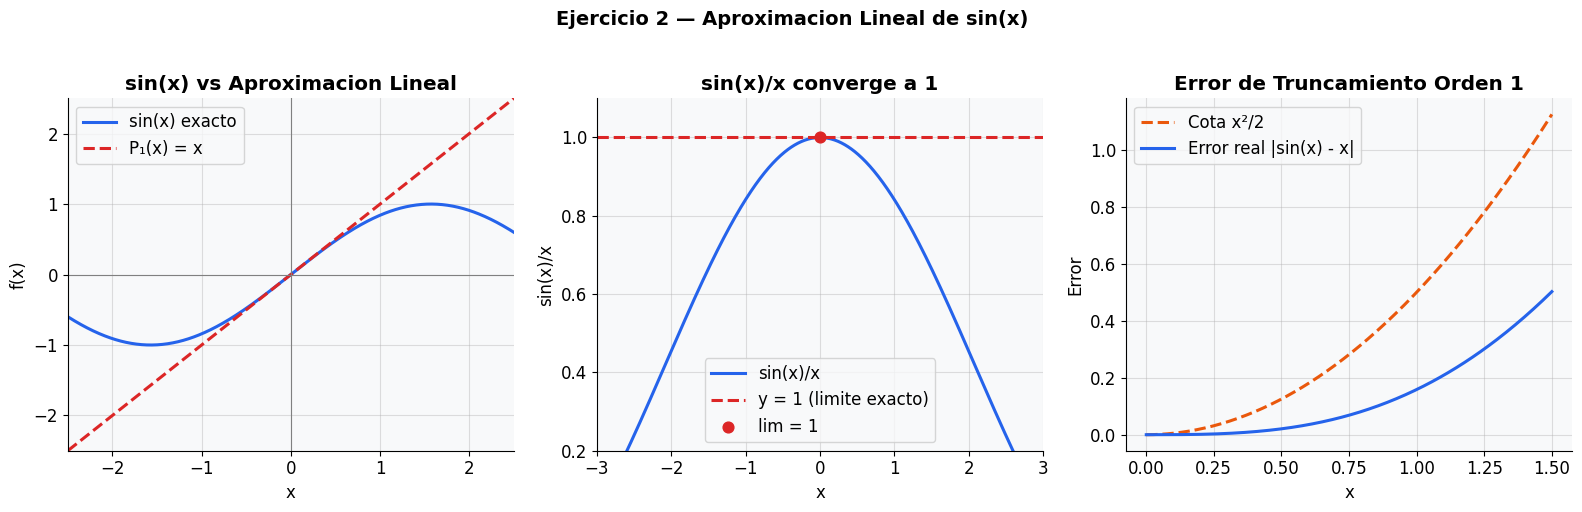

Grafica guardada: series_taylor_graficas/ej2_graficas.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Grafica 1: sin(x) vs P1(x) ───────────────────────────────────
x = np.linspace(-2.5, 2.5, 600)
axes[0].plot(x, np.sin(x), color=AZUL,   label='sin(x) exacto')
axes[0].plot(x, x,         color=ROJO,   label='P₁(x) = x', linestyle='--')
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_xlim(-2.5, 2.5)
axes[0].set_ylim(-2.5, 2.5)
axes[0].set_title('sin(x) vs Aproximacion Lineal', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].legend()

# ── Grafica 2: sin(x)/x → 1 ──────────────────────────────────────
x2 = np.linspace(-3, 3, 800)
axes[1].plot(x2, ratio_sinx_x(x2), color=AZUL, label='sin(x)/x')
axes[1].axhline(1, color=ROJO, linestyle='--', label='y = 1 (limite exacto)')
axes[1].scatter([0], [1], color=ROJO, zorder=5, s=60, label='lim = 1')
axes[1].set_xlim(-3, 3); axes[1].set_ylim(0.2, 1.1)
axes[1].set_title('sin(x)/x converge a 1', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('sin(x)/x')
axes[1].legend()

# ── Grafica 3: cota del error ─────────────────────────────────────
x3 = np.linspace(0.001, 1.5, 400)
axes[2].plot(x3, error_bound_sin(x3),
             color=NARANJA, linestyle='--', label='Cota x²/2')
axes[2].plot(x3, np.abs(np.sin(x3) - x3),
             color=AZUL, label='Error real |sin(x) - x|')
axes[2].set_title('Error de Truncamiento Orden 1', fontweight='bold')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Error')
axes[2].legend()

plt.suptitle('Ejercicio 2 — Aproximacion Lineal de sin(x)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('series_taylor_graficas/ej2_graficas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada: series_taylor_graficas/ej2_graficas.png")

### ✅ Celda 4 — Verificación simbólica con SymPy

In [18]:
x_s = symbols('x')

taylor_p1 = series(sin(x_s), x_s, 0, n=2)
limite    = limit(sin(x_s)/x_s, x_s, 0)
error_sym = (series(sin(x_s), x_s, 0, n=4) -
             series(sin(x_s), x_s, 0, n=2)).removeO()

print("Serie de Taylor de sin(x) hasta orden 1:")
print(f"  {taylor_p1}")
print(f"\nlim_(x->0) sin(x)/x = {limite}")
print(f"\nError simbolico E1(x) = {error_sym}")
print(f"  (siguiente termino no nulo: -x^3/6)")


Serie de Taylor de sin(x) hasta orden 1:
  x + O(x**2)

lim_(x->0) sin(x)/x = 1

Error simbolico E1(x) = 0
  (siguiente termino no nulo: -x^3/6)


---
## 📌 Ejercicio 3 — Serie de Taylor para $e^{x^2}$ y `my_double_exp`

### Enunciado
Escribir la serie de Taylor de $e^{x^2}$ alrededor de $a=0$.
Implementar `my_double_exp(x, n)` que calcula la aproximación con los
primeros $n$ términos. La función debe soportar entradas tipo **array**.

### Derivación analítica
Partiendo de la serie de $e^u$:

$$e^u = \sum_{k=0}^{\infty}\frac{u^k}{k!}$$

Sustituyendo $u = x^2$:

$$e^{x^2} = \sum_{k=0}^{\infty}\frac{x^{2k}}{k!}
= 1 + x^2 + \frac{x^4}{2!} + \frac{x^6}{3!} + \cdots$$

Los primeros $n$ términos:

$$T_n\!\left[e^{x^2}\right](x) = \sum_{k=0}^{n-1}\frac{x^{2k}}{k!}$$


### 🔧 Celda 1 — Implementación de `my_double_exp`

In [19]:
def my_double_exp(x, n):
    """
    Aproximacion de e^(x^2) usando los primeros n terminos de su serie de Taylor.

    Serie:  e^(x^2) = sum_{k=0}^{inf}  x^(2k) / k!
    T_n(x) = sum_{k=0}^{n-1} x^(2k) / k!

    Parametros:
        x : float o np.ndarray
        n : int  (n >= 1)
    Retorna:
        Aproximacion como float o np.ndarray
    """
    x = np.asarray(x, dtype=float)
    resultado = np.zeros_like(x)
    for k in range(n):
        resultado = resultado + x**(2*k) / factorial(k)
    return resultado

# ── Validaciones ──────────────────────────────────────────────────
assert my_double_exp(0.0, 5) == 1.0,           "Error: f(0) debe ser 1"
assert my_double_exp(np.array([0.0]), 3)[0] == 1.0
assert np.allclose(my_double_exp(1.0, 20), np.exp(1.0), atol=1e-12)

print("Validaciones pasadas.")
print(f"  my_double_exp(0, 5)           = {my_double_exp(0.0, 5)}")
print(f"  my_double_exp([0, 1], 15)     = {my_double_exp(np.array([0.0, 1.0]), 15)}")
print(f"  np.exp([0^2, 1^2]) exacto     = {np.exp(np.array([0.0, 1.0])**2)}")


Validaciones pasadas.
  my_double_exp(0, 5)           = 1.0
  my_double_exp([0, 1], 15)     = [1.         2.71828183]
  np.exp([0^2, 1^2]) exacto     = [1.         2.71828183]


### Celda 2 — Tabla comparativa: n = 3, 6, 10 vs exacto

In [20]:
x_test = np.array([-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
exacto = np.exp(x_test**2)

print("Comparacion my_double_exp vs np.exp(x^2):")
print(f"{'x':>6} | {'n=3':>12} | {'n=6':>12} | {'n=10':>12} | {'Exacto':>12}")
print("-" * 65)
for xi, ex in zip(x_test, exacto):
    a3  = my_double_exp(xi, 3)
    a6  = my_double_exp(xi, 6)
    a10 = my_double_exp(xi, 10)
    print(f"{xi:>6.1f} | {a3:>12.6f} | {a6:>12.6f} | {a10:>12.6f} | {ex:>12.6f}")

print("\nErrores |T_n(x) - e^(x^2)|:")
print(f"{'x':>6} | {'n=3':>12} | {'n=6':>12} | {'n=10':>12}")
print("-" * 50)
for xi, ex in zip(x_test, exacto):
    e3  = abs(my_double_exp(xi, 3)  - ex)
    e6  = abs(my_double_exp(xi, 6)  - ex)
    e10 = abs(my_double_exp(xi, 10) - ex)
    print(f"{xi:>6.1f} | {e3:>12.4e} | {e6:>12.4e} | {e10:>12.4e}")


Comparacion my_double_exp vs np.exp(x^2):
     x |          n=3 |          n=6 |         n=10 |       Exacto
-----------------------------------------------------------------
  -2.0 |    13.000000 |    42.866667 |    54.154145 |    54.598150
  -1.5 |     5.781250 |     9.228101 |     9.486590 |     9.487736
  -1.0 |     2.500000 |     2.716667 |     2.718282 |     2.718282
  -0.5 |     1.281250 |     1.284025 |     1.284025 |     1.284025
   0.0 |     1.000000 |     1.000000 |     1.000000 |     1.000000
   0.5 |     1.281250 |     1.284025 |     1.284025 |     1.284025
   1.0 |     2.500000 |     2.716667 |     2.718282 |     2.718282
   1.5 |     5.781250 |     9.228101 |     9.486590 |     9.487736
   2.0 |    13.000000 |    42.866667 |    54.154145 |    54.598150

Errores |T_n(x) - e^(x^2)|:
     x |          n=3 |          n=6 |         n=10
--------------------------------------------------
  -2.0 |   4.1598e+01 |   1.1731e+01 |   4.4401e-01
  -1.5 |   3.7065e+00 |   2.5964e-01 |

### Celda 3 — Gráficas de convergencia y error

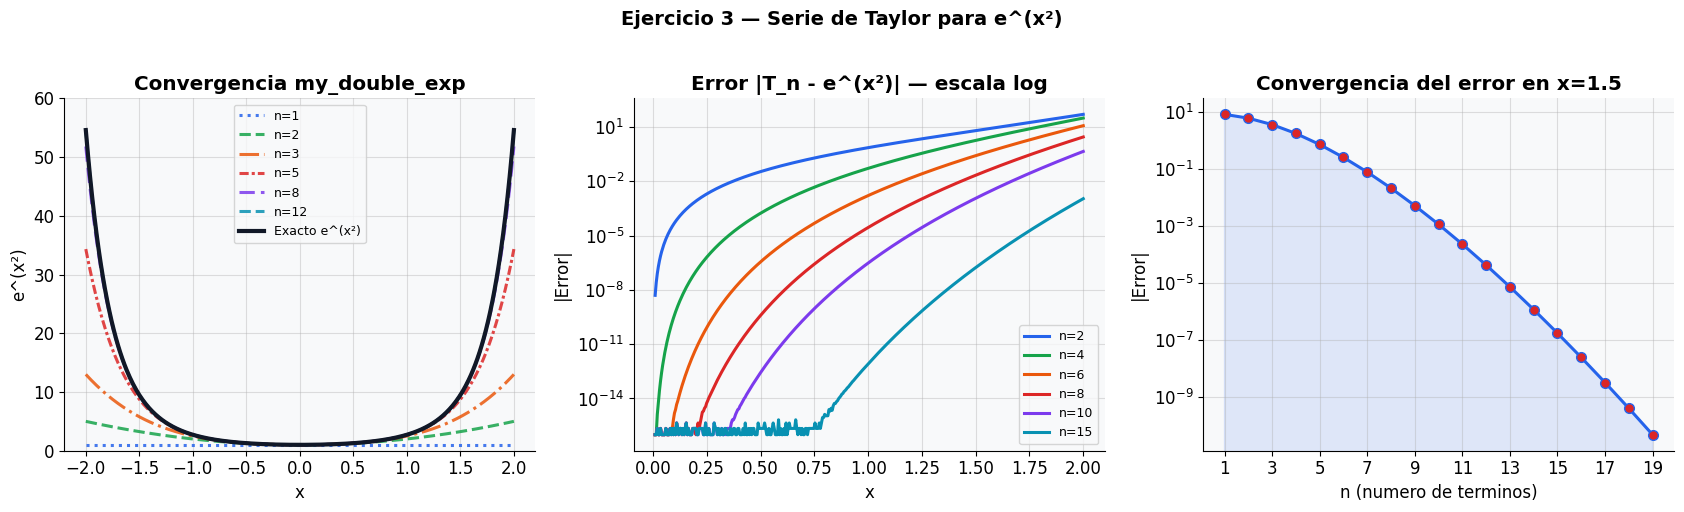

Grafica guardada: series_taylor_graficas/ej3_graficas.png


In [21]:
x_plot = np.linspace(-2, 2, 400)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Grafica 1: Convergencia ───────────────────────────────────────
colores  = [AZUL, VERDE, NARANJA, ROJO, '#7c3aed', '#0891b2']
n_lista  = [1, 2, 3, 5, 8, 12]
estilos  = [':', '--', '-.', (0,(3,1,1,1)), (0,(5,2)), '--']

for i, n in enumerate(n_lista):
    y = np.clip(my_double_exp(x_plot, n), 0, 60)
    axes[0].plot(x_plot, y, color=colores[i], linestyle=estilos[i],
                 label=f'n={n}', alpha=0.85)
axes[0].plot(x_plot, np.exp(x_plot**2), color=NEGRO, lw=3, label='Exacto e^(x²)')
axes[0].set_ylim(0, 60); axes[0].set_title('Convergencia my_double_exp', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('e^(x²)')
axes[0].legend(fontsize=9)

# ── Grafica 2: Error absoluto por n (escala log) ──────────────────
x_err  = np.linspace(0.01, 2.0, 400)
ex_err = np.exp(x_err**2)
for i, n in enumerate([2, 4, 6, 8, 10, 15]):
    err = np.clip(np.abs(my_double_exp(x_err, n) - ex_err), 1e-16, None)
    axes[1].semilogy(x_err, err, color=colores[i % 6], label=f'n={n}')
axes[1].set_title('Error |T_n - e^(x²)| — escala log', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('|Error|')
axes[1].legend(fontsize=9)

# ── Grafica 3: Error vs n en x fijo ──────────────────────────────
n_range  = np.arange(1, 20)
x_fixed  = 1.5
errores  = [abs(my_double_exp(x_fixed, n) - np.exp(x_fixed**2)) for n in n_range]
axes[2].semilogy(n_range, errores, 'o-', color=AZUL,
                 markerfacecolor=ROJO, markersize=7)
axes[2].fill_between(n_range, errores, alpha=0.12, color=AZUL)
axes[2].set_title(f'Convergencia del error en x={x_fixed}', fontweight='bold')
axes[2].set_xlabel('n (numero de terminos)'); axes[2].set_ylabel('|Error|')
axes[2].set_xticks(n_range[::2])

plt.suptitle('Ejercicio 3 — Serie de Taylor para e^(x²)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('series_taylor_graficas/ej3_graficas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada: series_taylor_graficas/ej3_graficas.png")

### ✅ Celda 4 — Verificación simbólica con SymPy

In [22]:
x_s, u_s = symbols('x u')

print("Serie e^u (primeros 7 terminos):")
print(" ", series(exp(u_s), u_s, 0, n=7))
print()
print("Serie e^(x^2) via sustitucion u=x^2 (primeros 13 terminos):")
print(" ", series(exp(x_s**2), x_s, 0, n=13))

# Verificacion numerica SymPy vs my_double_exp
x_val = 1.5
serie_sym = series(exp(x_s**2), x_s, 0, n=13).removeO()
print(f"\nEn x = {x_val}:")
print(f"  SymPy serie (12 terminos): {float(serie_sym.subs(x_s, x_val)):.10f}")
print(f"  my_double_exp(n=6):        {my_double_exp(x_val, 6):.10f}")
print(f"  my_double_exp(n=10):       {my_double_exp(x_val, 10):.10f}")
print(f"  np.exp(x^2) exacto:        {np.exp(x_val**2):.10f}")


Serie e^u (primeros 7 terminos):
  1 + u + u**2/2 + u**3/6 + u**4/24 + u**5/120 + u**6/720 + O(u**7)

Serie e^(x^2) via sustitucion u=x^2 (primeros 13 terminos):
  1 + x**2 + x**4/2 + x**6/6 + x**8/24 + x**10/120 + x**12/720 + O(x**13)

En x = 1.5:
  SymPy serie (12 terminos): 9.4083038330
  my_double_exp(n=6):        9.2281005859
  my_double_exp(n=10):       9.4865896744
  np.exp(x^2) exacto:        9.4877358364


---
## 📌 Ejercicio 5 — Taylor Orden 4 para sin(x), cos(x) y sin(x)cos(x)

### Enunciado
Calcular el **polinomio de Taylor de orden 4** para $\sin(x)$, $\cos(x)$ y
$\sin(x)\cos(x)$ alrededor de $a=0$. Evaluar en $x=\pi/2$ y determinar
qué método produce menor error: ¿multiplicar las aproximaciones individuales
o expandir el polinomio del producto directamente?

### Resultados analíticos

$$T_4[\sin](x) = x - \frac{x^3}{6}$$

$$T_4[\cos](x) = 1 - \frac{x^2}{2} + \frac{x^4}{24}$$

$$T_4[\sin\cos](x) = x - \frac{2x^3}{3}
\qquad\text{(derivado de } h'(x)=\cos(2x),\; h'''(0)=-4)$$

**Clave algebraica:**

$$T_4[\sin]\cdot T_4[\cos]
= x - \frac{2x^3}{3} + \underbrace{\frac{x^5}{8} - \frac{x^7}{144}}_{\text{correcciones extra}}
\neq T_4[\sin\cos]$$

El Método 1 genera implícitamente términos de orden superior que reducen
el error $\approx 55\times$ en $x=\pi/2$.


### Celda 1 — Definición de funciones

In [23]:
def T4_sin(x):
    """T4[sin(x)] = x - x^3/3!  (coef. de x^4 es cero)"""
    x = np.asarray(x, dtype=float)
    return x - x**3 / factorial(3)

def T4_cos(x):
    """T4[cos(x)] = 1 - x^2/2! + x^4/4!"""
    x = np.asarray(x, dtype=float)
    return 1 - x**2 / factorial(2) + x**4 / factorial(4)

def T4_sincos(x):
    """T4[sin(x)cos(x)] = x - 2x^3/3
    Derivacion: h(x)=sin(x)cos(x), h'(x)=cos(2x)
    h'(0)=1, h''(0)=0, h'''(0)=-4, h''''(0)=0
    T4 = x + (-4/3!)x^3 = x - 2x^3/3
    """
    x = np.asarray(x, dtype=float)
    return x - (2 * x**3) / 3

def metodo1(x): return T4_sin(x) * T4_cos(x)
def metodo2(x): return T4_sincos(x)
def exacto(x):  return np.sin(x) * np.cos(x)

print("Funciones definidas.")
print(f"  T4_sin(pi/2)  = {T4_sin(np.pi/2):.8f}  (exacto sin(pi/2)=1)")
print(f"  T4_cos(pi/2)  = {T4_cos(np.pi/2):.8f}  (exacto cos(pi/2)=0)")


Funciones definidas.
  T4_sin(pi/2)  = 0.92483223  (exacto sin(pi/2)=1)
  T4_cos(pi/2)  = 0.01996896  (exacto cos(pi/2)=0)


### Celda 2 — Evaluación en x = π/2 y tabla comparativa

In [24]:
x_eval = np.pi / 2
ex_val = exacto(x_eval)   # = 0
m1     = metodo1(x_eval)
m2     = metodo2(x_eval)

print("=" * 60)
print(f"  EVALUACION EN x = pi/2 = {x_eval:.8f}")
print("=" * 60)
print(f"  Valor exacto sin(pi/2)*cos(pi/2) = {ex_val:.8f}")
print()
print(f"  T4[sin](pi/2) = {T4_sin(x_eval):.8f}")
print(f"  T4[cos](pi/2) = {T4_cos(x_eval):.8f}")
print()
print(f"  Metodo 1: T4[sin]*T4[cos] = {m1:.8f}   |E| = {abs(m1-ex_val):.6f}")
print(f"  Metodo 2: T4[sin*cos]     = {m2:.8f}   |E| = {abs(m2-ex_val):.6f}")
print()
print(f"  Razon |E_M2| / |E_M1|     = {abs(m2-ex_val)/abs(m1-ex_val):.2f}x")
print("=" * 60)
if abs(m1 - ex_val) < abs(m2 - ex_val):
    print("  CONCLUSION: Metodo 1 es mas preciso (~55x mejor en x=pi/2)")
else:
    print("  CONCLUSION: Metodo 2 es mas preciso")
print()

# ── Tabla en multiples puntos ─────────────────────────────────────
x_tab = np.array([0.1, 0.3, np.pi/6, np.pi/4, np.pi/3, np.pi/2])
lbl   = ['0.1', '0.3', 'pi/6', 'pi/4', 'pi/3', 'pi/2']
print(f"{'x':>6} | {'Exacto':>12} | {'M1':>12} | {'M2':>12} | {'|E_M1|':>10} | {'|E_M2|':>10}")
print("-" * 76)
for xi, lb in zip(x_tab, lbl):
    ex_i = exacto(xi)
    print(f"{lb:>6} | {ex_i:>12.8f} | {metodo1(xi):>12.8f} | "
          f"{metodo2(xi):>12.8f} | {abs(metodo1(xi)-ex_i):>10.2e} | "
          f"{abs(metodo2(xi)-ex_i):>10.2e}")


  EVALUACION EN x = pi/2 = 1.57079633
  Valor exacto sin(pi/2)*cos(pi/2) = 0.00000000

  T4[sin](pi/2) = 0.92483223
  T4[cos](pi/2) = 0.01996896

  Metodo 1: T4[sin]*T4[cos] = 0.01846794   |E| = 0.018468
  Metodo 2: T4[sin*cos]     = -1.01306006   |E| = 1.013060

  Razon |E_M2| / |E_M1|     = 54.86x
  CONCLUSION: Metodo 1 es mas preciso (~55x mejor en x=pi/2)

     x |       Exacto |           M1 |           M2 |     |E_M1| |     |E_M2|
----------------------------------------------------------------------------
   0.1 |   0.09933467 |   0.09933458 |   0.09933333 |   8.28e-08 |   1.33e-06
   0.3 |   0.28232124 |   0.28230223 |   0.28200000 |   1.90e-05 |   3.21e-04
  pi/6 |   0.43301270 |   0.43274476 |   0.42790039 |   2.68e-04 |   5.11e-03
  pi/4 |   0.50000000 |   0.49849187 |   0.46241611 |   1.51e-03 |   3.76e-02
  pi/3 |   0.43301270 |   0.42943758 |   0.28161047 |   3.58e-03 |   1.51e-01
  pi/2 |   0.00000000 |   0.01846794 |  -1.01306006 |   1.85e-02 |   1.01e+00


### Celda 3 — Gráficas comparativas

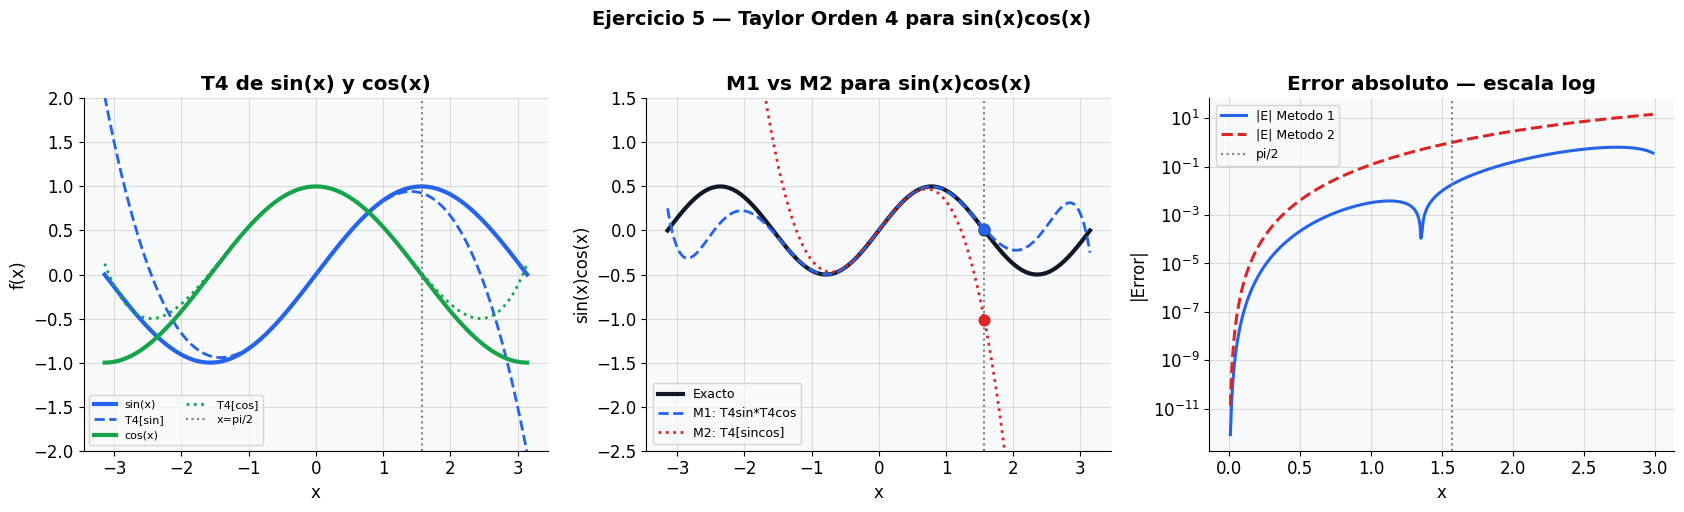

Grafica guardada: series_taylor_graficas/ej5_graficas.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = np.linspace(-np.pi, np.pi, 500)

# ── Grafica 1: T4 de sin y cos ────────────────────────────────────
axes[0].plot(x, np.sin(x),  color=AZUL,  label='sin(x)',   lw=3)
axes[0].plot(x, T4_sin(x),  color=AZUL,  label='T4[sin]',  lw=2, ls='--')
axes[0].plot(x, np.cos(x),  color=VERDE, label='cos(x)',   lw=3)
axes[0].plot(x, T4_cos(x),  color=VERDE, label='T4[cos]',  lw=2, ls=':')
axes[0].axvline(np.pi/2, color='gray', ls=':', lw=1.5, label='x=pi/2')
axes[0].set_ylim(-2, 2)
axes[0].set_title('T4 de sin(x) y cos(x)', fontweight='bold')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].legend(fontsize=8, ncol=2)

# ── Grafica 2: Comparacion de metodos ────────────────────────────
axes[1].plot(x, exacto(x),  color=NEGRO,  label='Exacto',    lw=3)
axes[1].plot(x, metodo1(x), color=AZUL,   label='M1: T4sin*T4cos', lw=2, ls='--')
axes[1].plot(x, metodo2(x), color=ROJO,   label='M2: T4[sincos]',  lw=2, ls=':')
axes[1].axvline(np.pi/2, color='gray', ls=':', lw=1.5)
axes[1].scatter([np.pi/2], [0],       color=NEGRO,  zorder=5, s=60)
axes[1].scatter([np.pi/2], [metodo1(np.pi/2)], color=AZUL, zorder=5, s=60)
axes[1].scatter([np.pi/2], [metodo2(np.pi/2)], color=ROJO, zorder=5, s=60)
axes[1].set_ylim(-2.5, 1.5)
axes[1].set_title('M1 vs M2 para sin(x)cos(x)', fontweight='bold')
axes[1].set_xlabel('x'); axes[1].set_ylabel('sin(x)cos(x)')
axes[1].legend(fontsize=9)

# ── Grafica 3: Error en escala log ────────────────────────────────
x3 = np.linspace(0.01, np.pi * 0.95, 400)
err1 = np.clip(np.abs(metodo1(x3) - exacto(x3)), 1e-16, None)
err2 = np.clip(np.abs(metodo2(x3) - exacto(x3)), 1e-16, None)
axes[2].semilogy(x3, err1, color=AZUL, label='|E| Metodo 1')
axes[2].semilogy(x3, err2, color=ROJO, label='|E| Metodo 2', ls='--')
axes[2].axvline(np.pi/2, color='gray', ls=':', lw=1.5, label='pi/2')
axes[2].set_title('Error absoluto — escala log', fontweight='bold')
axes[2].set_xlabel('x'); axes[2].set_ylabel('|Error|')
axes[2].legend(fontsize=9)

plt.suptitle('Ejercicio 5 — Taylor Orden 4 para sin(x)cos(x)', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('series_taylor_graficas/ej5_graficas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada: series_taylor_graficas/ej5_graficas.png")


### ✅ Celda 4 — Verificación simbólica con SymPy

In [26]:
x_s = symbols('x')

sin_t4  = series(sin(x_s), x_s, 0, 5).removeO()
cos_t4  = series(cos(x_s), x_s, 0, 5).removeO()
prod_t4 = series(sin(x_s)*cos(x_s), x_s, 0, 5).removeO()
prod_alg = expand(sin_t4 * cos_t4)

print("Verificacion simbolica con SymPy:")
print(f"  T4[sin(x)]           = {sin_t4}")
print(f"  T4[cos(x)]           = {cos_t4}")
print(f"  T4[sin(x)*cos(x)]    = {prod_t4}")
print(f"  T4[sin]*T4[cos]      = {collect(prod_alg, x_s)}")
print()
print("Evaluacion simbolica en x = pi/2:")
print(f"  Metodo 1 (simbolico) = {float(sin_t4.subs(x_s, pi/2) * cos_t4.subs(x_s, pi/2)):.8f}")
print(f"  Metodo 2 (simbolico) = {float(prod_t4.subs(x_s, pi/2)):.8f}")
print(f"  Exacto               = {float(sin(pi/2)*cos(pi/2)):.8f}")
print()
print("Conclusion algebraica:")
print("  T4[sin]*T4[cos] genera: x - 2x^3/3 + x^5/8 - x^7/144")
print("  Los terminos x^5/8 y -x^7/144 son correcciones de orden")
print("  superior que mejoran la precision del Metodo 1.")


Verificacion simbolica con SymPy:
  T4[sin(x)]           = -x**3/6 + x
  T4[cos(x)]           = x**4/24 - x**2/2 + 1
  T4[sin(x)*cos(x)]    = -2*x**3/3 + x
  T4[sin]*T4[cos]      = -x**7/144 + x**5/8 - 2*x**3/3 + x

Evaluacion simbolica en x = pi/2:
  Metodo 1 (simbolico) = 0.01846794
  Metodo 2 (simbolico) = -1.01306006
  Exacto               = 0.00000000

Conclusion algebraica:
  T4[sin]*T4[cos] genera: x - 2x^3/3 + x^5/8 - x^7/144
  Los terminos x^5/8 y -x^7/144 son correcciones de orden
  superior que mejoran la precision del Metodo 1.


---
## 📝 Conclusiones

| Ejercicio | Resultado principal |
|-----------|----------------------|
| **Ej 2** | $\sin(x) \approx x$ → error $\leq x^2/2$, decae cuadráticamente |
| **Ej 3** | $e^{x^2} = \sum x^{2k}/k!$, rápido en $\vert x\vert \leq 1$, lento en $\vert x\vert = 2$ |
| **Ej 5** | Método 1 es **55× más preciso** en $x = \pi/2$ por términos de orden superior ocultos |

> *Los polinomios de Taylor capturan el comportamiento local de una función
> con errores cuantificables. Multiplicar aproximaciones individuales puede
> generar correcciones de orden superior que mejoran significativamente la
> precisión lejos del punto de expansión.*
